
# Newton's Algorithm for Logit MLE: One-Parameter Example

This notebook shows Newton's method in the simplest possible logit model:

$$
P(y_i = 1 \mid x_i) = f(x_i) = \frac{e^{\beta x_i}}{1 + e^{\beta x_i}}
$$

There is only **one parameter** to estimate: $(\beta)$.

The goal is to find the value of $(\beta)$ that maximizes the log-likelihood.



## 1. Create a tiny dataset

We use one explanatory variable \(x\) and a binary outcome \(y\).


In [64]:

import numpy as np
import matplotlib.pyplot as plt

# One regressor, one binary outcome
np.random.seed(42)

n = 1000
beta_true = 1.0

x = np.random.normal(size=n)
x = x - np.mean(x)

p_true = logistic(beta_true * x)
y = np.random.binomial(1, p_true)



## 2. Define the logit probability

For a given value of $(\beta)$, the model predicts:

$$
p_i = f(x_i)
$$


In [93]:

def logistic(z):
    return np.exp(z) / (1 + np.exp(z))

# Example: predicted probabilities when beta = 1
true_beta = 1
p = logistic(true_beta * x)


## 3. Log-likelihood

The log-likelihood for the one-parameter logit model is:

$$
\ell(\beta) = \sum_i \left[y_i \log(p_i) + (1-y_i) \log(1-p_i)\right]
$$

Newton's method will choose \(\beta\) to make this as large as possible.


In [94]:

def loglik(beta):
    p = logistic(beta * x)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

loglik(1)


np.float64(-599.1110611279491)


## 4. Score and Hessian

Newton's method uses two ingredients.

The **score**, or first derivative:

$$
S(\beta) = \frac{d\ell(\beta)}{d\beta}
= \sum_i x_i (y_i - p_i)
$$

The **Hessian**, or second derivative:

$$
H(\beta) = \frac{d^2\ell(\beta)}{d\beta^2}
= -\sum_i x_i^2 p_i(1-p_i)
$$

For this one-parameter example, both are just scalars.


In [68]:

def score(beta):
    p = logistic(beta * x)
    return np.sum(x * (y - p))

def hessian(beta):
    p = logistic(beta * x)
    return -np.sum(x**2 * p * (1 - p))

print("score at beta=0:", score(0))
print("hessian at beta=0:", hessian(0))


score at beta=0: 202.45825648366434
hessian at beta=0: -239.47624743287932



## 5. Newton update

Newton's update rule for maximizing a function is:

$$
\beta_{new} = \beta_{old} - \frac{S(\beta_{old})}{H(\beta_{old})}
$$

Since the log-likelihood is concave, this update usually moves quickly toward the maximum.


In [88]:

beta = 0.0

for step in range(5):
    s = score(beta)
    h = hessian(beta)
    beta_new = beta - s / h
    
    print(f"step {step}")
    print(f"  beta old   = {beta:.6f}")
    print(f"  loglik     = {loglik(beta):.6f}")
    print(f"  score      = {s:.6f}")
    print(f"  hessian    = {h:.6f}")
    print(f"  beta new   = {beta_new:.6f}")
    print()
    
    beta = beta_new


step 0
  beta old   = 0.000000
  loglik     = -693.147181
  score      = 202.458256
  hessian    = -239.476247
  beta new   = 0.845421

step 1
  beta old   = 0.845421
  loglik     = -601.418037
  score      = 26.715231
  hessian    = -158.922963
  beta new   = 1.013523

step 2
  beta old   = 1.013523
  loglik     = -599.074922
  score      = 1.731828
  hessian    = -138.599499
  beta new   = 1.026018

step 3
  beta old   = 1.026018
  loglik     = -599.064064
  score      = 0.009000
  hessian    = -137.160819
  beta new   = 1.026084

step 4
  beta old   = 1.026084
  loglik     = -599.064064
  score      = 0.000000
  hessian    = -137.153294
  beta new   = 1.026084




## 6. Store the path of the algorithm

Now we repeat the calculation and save every value of \(\beta\).


In [85]:

beta = 0.0
path = [beta]

for step in range(3):
    beta = beta - score(beta) / hessian(beta)
    path.append(beta)

path = np.array(path)
path


array([0.    , 0.8454, 1.0135, 1.026 ])


## 7. Plot the log-likelihood and Newton steps

The dots show the values tried by Newton's method.


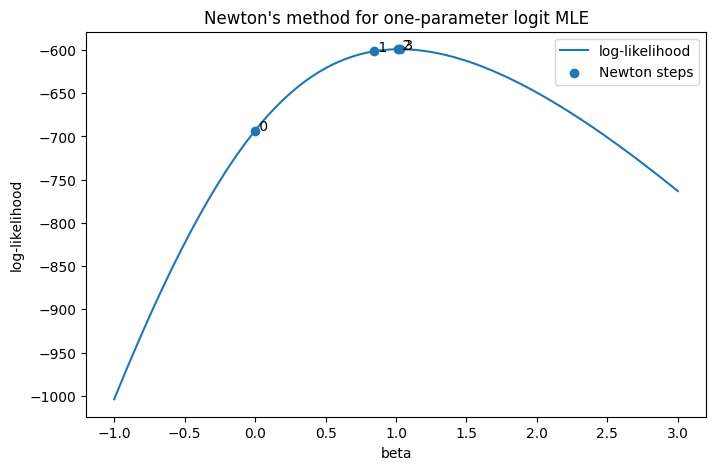

True beta: 1
Estimated beta: 1.0260836185097553
Error: 0.02608361850975527


In [91]:

grid = np.linspace(-1, 3, 300)
ll_values = np.array([loglik(b) for b in grid])

plt.figure(figsize=(8, 5))
plt.plot(grid, ll_values, label="log-likelihood")
plt.scatter(path, [loglik(b) for b in path], zorder=3, label="Newton steps")

for i, b in enumerate(path):
    plt.text(b, loglik(b), f" {i}")

plt.xlabel("beta")
plt.ylabel("log-likelihood")
plt.title("Newton's method for one-parameter logit MLE")
plt.legend()
plt.show()

print("True beta:", true_beta)
print("Estimated beta:", beta)
print("Error:", beta - true_beta)



## 8. Interpretation

At each step:

1. Compute the slope of the log-likelihood: the **score**.
2. Compute the curvature: the **Hessian**.
3. Move to a better value using:

$$
\beta_{new} = \beta_{old} - \frac{S(\beta_{old})}{H(\beta_{old})}
$$

When the score becomes close to zero, the algorithm has found the maximum $\implies$ $\beta$ does no longer move

